# このnotebookでは

勾配消失がなぜ起きるのかを、連鎖律・小さな数値実験・残差接続の式変形を通じて直感的に理解する。

結論:

深いネットワークでは、逆伝播で各層の微分が何度も掛け合わされるため、1未満の係数が続くと勾配は急速に小さくなる。残差接続では `x_(l+1) = x_l + F(x_l)` により、逆伝播に `I + dF/dx_l` が現れるので、少なくとも恒等写像の経路が残り、勾配が浅い層まで届きやすくなる。

## このノートの見方

1. まず、勾配消失を「小さい数の連続した掛け算」として掴む。
2. 次に、連鎖律とヤコビアン積の形で何が起きているかを見る。
3. その後、plain MLP と residual MLP の勾配ノルムを比較する。
4. 最後に、残差接続がなぜ効くのかを式と図式でまとめる。

このノートでは、理解を優先して小さな MLP を使う。ResNet や Transformer でも、本質は同じである。

In [ ]:
import math
import platform
import sys

import matplotlib.pyplot as plt
import matplotlib_fontja
import numpy as np
import torch
import torch.nn as nn

In [ ]:
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print(
    "MPS available:",
    torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False,
)
print("CUDA available:", torch.cuda.is_available())

torch.manual_seed(7)
np.random.seed(7)
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8, 4)

Python: 3.13.3
Platform: macOS-26.4.1-arm64-arm-64bit-Mach-O
Torch: 2.11.0
NumPy: 2.4.3
MPS available: True
CUDA available: False


## 1. まずは 1 次元で直感を作る

出力が `y = f_3(f_2(f_1(x)))` だとすると、連鎖律により

`dy/dx = f_3'(h_2) * f_2'(h_1) * f_1'(x)`

となる。もし各微分が `0.8` 程度でも、10 回掛けると `0.8^10 ≈ 0.107`、50 回掛けると `0.8^50 ≈ 0.000014` になる。つまり、各層で少しずつしか縮んでいないように見えても、深くなると勾配は一気に小さくなる。

0.95 を掛け続ける depth=10 -> 0.598737 , depth=50 -> 0.076945
0.80 を掛け続ける depth=10 -> 0.107374 , depth=50 -> 0.000014
0.50 を掛け続ける depth=10 -> 0.000977 , depth=50 -> 0.000000


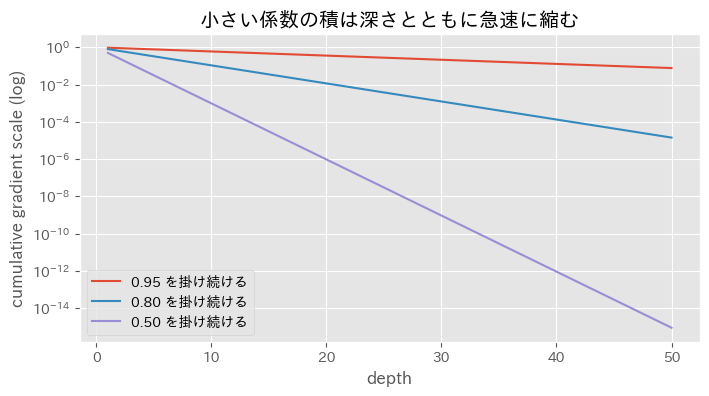

In [ ]:
depths = np.arange(1, 51)
local_gradients = {
    "0.95 を掛け続ける": 0.95**depths,
    "0.80 を掛け続ける": 0.80**depths,
    "0.50 を掛け続ける": 0.50**depths,
}

for label, values in local_gradients.items():
    print(
        label, "depth=10 ->", f"{values[9]:.6f}", ", depth=50 ->", f"{values[-1]:.6f}"
    )

plt.figure()
for label, values in local_gradients.items():
    plt.plot(depths, values, label=label)
plt.yscale("log")
plt.xlabel("depth")
plt.ylabel("cumulative gradient scale (log)")
plt.title("小さい係数の積は深さとともに急速に縮む")
plt.legend()
plt.show()

## 2. ベクトル版ではヤコビアンの積になる

実際のネットワークでは、各層はスカラーではなくベクトルを扱う。そのとき逆伝播は、各層のヤコビアンを掛け合わせる形になる。

```text
dL/dx_0 = dL/dx_L · dx_L/dx_(L-1) · dx_(L-1)/dx_(L-2) · ... · dx_1/dx_0
```

ここで各ヤコビアンの特異値が平均して 1 より小さければ、勾配ノルムは層をさかのぼるたびに縮みやすい。活性化関数の導関数が小さい領域に入ることも、重み行列のスケールが小さすぎることも、この縮みを後押しする。

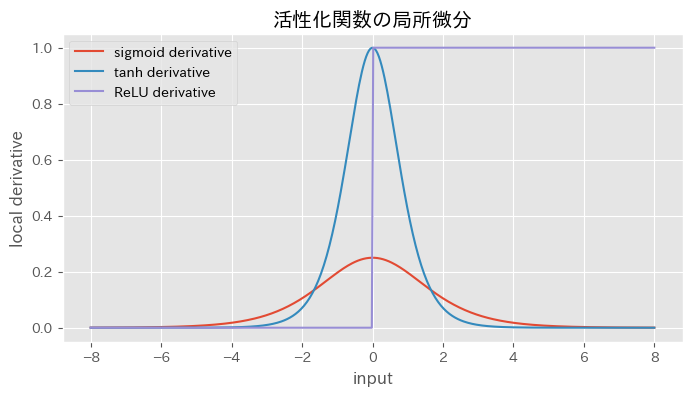

In [ ]:
x = torch.linspace(-8, 8, 400, requires_grad=True)
sigmoid_y = torch.sigmoid(x)
sigmoid_grad = torch.autograd.grad(sigmoid_y.sum(), x, retain_graph=True)[0]
tanh_y = torch.tanh(x)
tanh_grad = torch.autograd.grad(tanh_y.sum(), x, retain_graph=True)[0]
relu_y = torch.relu(x)
relu_grad = torch.autograd.grad(relu_y.sum(), x)[0]

plt.figure()
plt.plot(x.detach(), sigmoid_grad.detach(), label="sigmoid derivative")
plt.plot(x.detach(), tanh_grad.detach(), label="tanh derivative")
plt.plot(x.detach(), relu_grad.detach(), label="ReLU derivative")
plt.xlabel("input")
plt.ylabel("local derivative")
plt.title("活性化関数の局所微分")
plt.legend()
plt.show()

sigmoid や tanh は飽和領域に入ると導関数が小さくなる。そうすると、その層を通るたびに勾配が縮みやすい。ReLU は正の領域なら導関数が 1 なので、少なくとも活性化関数だけが原因で毎回縮むわけではないが、重み行列のスケールや深さの影響は依然として残る。

## 3. 残差接続が入ると何が変わるか

plain block では

`x_(l+1) = F(x_l)`

なので、逆伝播は

`dL/dx_l = dL/dx_(l+1) · dF/dx_l`

となる。ここでは毎回 `dF/dx_l` を掛けるしかない。

一方、residual block では

`x_(l+1) = x_l + F(x_l)`

なので、逆伝播は

`dL/dx_l = dL/dx_(l+1) · (I + dF/dx_l)`

となる。重要なのは、`I` があるので `F` が小さくても、入力をそのまま通す経路が常に残ることだ。これが「勾配の逃げ道」であり、深い層でも学習しやすくなる大きな理由である。

```text
plain:     x_l ──> F ──> x_(l+1)
                   ^
                   逆伝播は F の微分だけに依存

residual:  x_l ──> (+) ──> x_(l+1)
             └──> F ──┘
                   ^
                   逆伝播では I + dF/dx_l が効く
```

In [ ]:
class PlainBlock(nn.Module):
    def __init__(self, width: int, scale: float = 0.2):
        super().__init__()
        self.linear = nn.Linear(width, width)
        nn.init.normal_(self.linear.weight, mean=0.0, std=scale / math.sqrt(width))
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return torch.tanh(self.linear(x))


class ResidualBlock(nn.Module):
    def __init__(self, width: int, scale: float = 0.2):
        super().__init__()
        self.linear = nn.Linear(width, width)
        nn.init.normal_(self.linear.weight, mean=0.0, std=scale / math.sqrt(width))
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return x + torch.tanh(self.linear(x))


class DeepMLP(nn.Module):
    def __init__(self, block_cls, width: int, depth: int, scale: float = 0.2):
        super().__init__()
        self.blocks = nn.ModuleList(
            [block_cls(width, scale=scale) for _ in range(depth)]
        )
        self.head = nn.Linear(width, 1)
        nn.init.normal_(self.head.weight, mean=0.0, std=1.0 / math.sqrt(width))
        nn.init.zeros_(self.head.bias)

    def forward_with_activations(self, x):
        activations = [x]
        h = x
        for block in self.blocks:
            h = block(h)
            activations.append(h)
        out = self.head(h)
        return out, activations

In [ ]:
def measure_gradient_flow(block_cls, depth: int, width: int = 32, scale: float = 0.2):
    torch.manual_seed(7)
    model = DeepMLP(block_cls, width=width, depth=depth, scale=scale)
    x = torch.randn(1, width, requires_grad=True)

    output, activations = model.forward_with_activations(x)
    for activation in activations:
        activation.retain_grad()

    loss = (output**2).mean()
    loss.backward()

    grad_norms = torch.tensor([a.grad.norm().item() for a in activations])
    activation_norms = torch.tensor([a.detach().norm().item() for a in activations])
    return {
        "loss": float(loss.item()),
        "grad_norms": grad_norms,
        "activation_norms": activation_norms,
    }

plain input-side grad norm : 0.000000e+00
residual input-side grad norm: 4.202006e+00


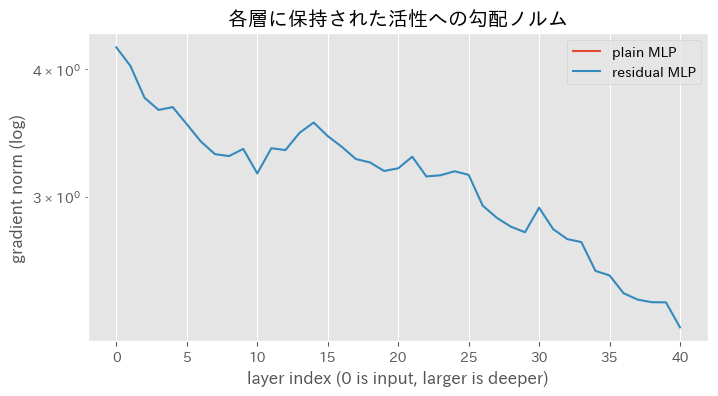

In [ ]:
depth = 40
plain_stats = measure_gradient_flow(PlainBlock, depth=depth)
residual_stats = measure_gradient_flow(ResidualBlock, depth=depth)
layers = np.arange(depth + 1)

print("plain input-side grad norm :", f"{plain_stats['grad_norms'][0].item():.6e}")
print("residual input-side grad norm:", f"{residual_stats['grad_norms'][0].item():.6e}")

plt.figure()
plt.plot(layers, plain_stats["grad_norms"], label="plain MLP")
plt.plot(layers, residual_stats["grad_norms"], label="residual MLP")
plt.yscale("log")
plt.xlabel("layer index (0 is input, larger is deeper)")
plt.ylabel("gradient norm (log)")
plt.title("各層に保持された活性への勾配ノルム")
plt.legend()
plt.show()

このグラフでは、横軸の 0 が入力に最も近い浅い側である。plain MLP では浅い層ほど勾配ノルムが急激に小さくなりやすい。residual MLP では同じ深さでも浅い層の勾配が比較的大きく保たれやすい。つまり、残差接続は「深いところで作られた誤差信号が、前の層へ戻るための直通路」を作っている。

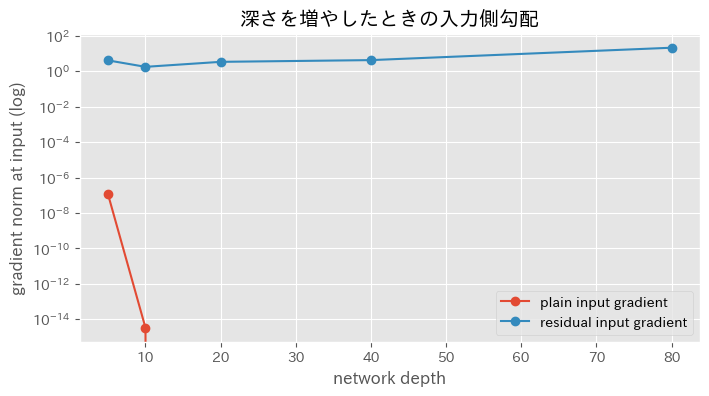

depth= 5: plain=1.202698e-07, residual=4.067898e+00
depth=10: plain=3.404627e-15, residual=1.754623e+00
depth=20: plain=0.000000e+00, residual=3.356622e+00
depth=40: plain=0.000000e+00, residual=4.202006e+00
depth=80: plain=0.000000e+00, residual=2.099322e+01


In [ ]:
depth_candidates = [5, 10, 20, 40, 80]
plain_input_grads = []
residual_input_grads = []

for depth in depth_candidates:
    plain_input_grads.append(
        measure_gradient_flow(PlainBlock, depth=depth)["grad_norms"][0].item()
    )
    residual_input_grads.append(
        measure_gradient_flow(ResidualBlock, depth=depth)["grad_norms"][0].item()
    )

plt.figure()
plt.plot(depth_candidates, plain_input_grads, marker="o", label="plain input gradient")
plt.plot(
    depth_candidates, residual_input_grads, marker="o", label="residual input gradient"
)
plt.yscale("log")
plt.xlabel("network depth")
plt.ylabel("gradient norm at input (log)")
plt.title("深さを増やしたときの入力側勾配")
plt.legend()
plt.show()

for depth, plain_value, residual_value in zip(
    depth_candidates, plain_input_grads, residual_input_grads
):
    print(f"depth={depth:>2}: plain={plain_value:.6e}, residual={residual_value:.6e}")

## 4. もう一段だけ理論寄りに見る

線形近似で各ブロックを考えると、plain は

`x_(l+1) ≈ A_l x_l`

なので、全体は `A_L A_(L-1) ... A_1 x_0` になる。各 `A_l` のノルムが 1 より少し小さいだけでも、積は急速に縮む。

一方 residual は

`x_(l+1) ≈ (I + A_l) x_l`

なので、各層が完全に新しい変換を作るというより、「恒等写像から少しだけずらす」形になる。これは最適化しやすく、逆伝播でも恒等成分が残るため勾配が流れやすい。

plain largest singular value   : 1.385394e-33
plain smallest singular value  : 1.521810e-42
residual largest singular value: 1.860918e+00
residual smallest singular value: 6.050770e-01


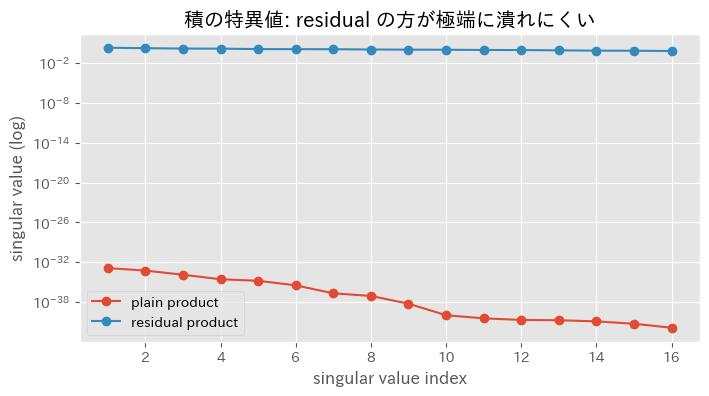

In [ ]:
torch.manual_seed(7)
matrix_size = 16
depth = 30
scale = 0.08

plain_product = torch.eye(matrix_size)
residual_product = torch.eye(matrix_size)

for _ in range(depth):
    A = torch.randn(matrix_size, matrix_size) * scale / math.sqrt(matrix_size)
    plain_product = A @ plain_product
    residual_product = (torch.eye(matrix_size) + A) @ residual_product

plain_singular_values = torch.linalg.svdvals(plain_product)
residual_singular_values = torch.linalg.svdvals(residual_product)

print("plain largest singular value   :", f"{plain_singular_values.max().item():.6e}")
print("plain smallest singular value  :", f"{plain_singular_values.min().item():.6e}")
print(
    "residual largest singular value:", f"{residual_singular_values.max().item():.6e}"
)
print(
    "residual smallest singular value:", f"{residual_singular_values.min().item():.6e}"
)

plt.figure(figsize=(8, 4))
indices = np.arange(1, matrix_size + 1)
plt.plot(
    indices, plain_singular_values.detach().numpy(), marker="o", label="plain product"
)
plt.plot(
    indices,
    residual_singular_values.detach().numpy(),
    marker="o",
    label="residual product",
)
plt.yscale("log")
plt.xlabel("singular value index")
plt.ylabel("singular value (log)")
plt.title("積の特異値: residual の方が極端に潰れにくい")
plt.legend()
plt.show()

## 5. よくある誤解

- 残差接続は勾配消失を完全になくす魔法ではない。重みスケール、初期化、正規化、活性化関数は依然として重要である。
- 残差接続は「表現力を下げる」のではなく、少なくとも恒等写像から始められるため、深いモデルを最適化しやすくする。
- Transformer で residual connection が重要なのも同じ理由で、深い stack を通っても情報と勾配の通り道が残るからである。

## まとめ

勾配消失の本質は、逆伝播が各層の局所微分の積になることにある。各層で少しずつ縮むだけでも、深さが増えると全体の勾配は指数的に小さくなりうる。残差接続は `I + dF/dx` を通じて恒等成分を残すため、勾配が浅い層まで届きやすくなる。深いネットワークが学習しやすくなるのは、表現力が増えるからだけでなく、最適化の地形が大幅に改善されるからである。